## Clinical Data Preprocessing
Steps include:

1. Cohort definition: filter RA (TACERA), remove (VACCINE) from df_clinical, save as df_clinical_ra_only
2. Raw data audit (df_clinical_ra_only, df_steroids, df_meds) and variance report
3. Individual dataset cleaning (clean each table):
4. a. df_clinical_ra_only: type fixing, standardise binary, missing values, encoding categories (gender, race), keep digest for merging, remove redundancies (inkl. duplicate columns, constant values, highly missing features). Export as df_clinical_ra_only_processed
4. b. df_steroids: aggregate (to a patient level), type fixing, missing values, encoding, etc. Export as df_steroids_processed
4. c. df_meds: aggregate (to a patient level), type fixing, missing values, encoding. Export as df_meds_processed
5. Merge df_clinical_ra_only_processed, df_steroids_processed, df_meds_processed into df_clinical_processed_final (one row per patient, all clinical data in one table)

## Add common imports
From /src/01_common_imports.py and from other relevant /src/ files

In [1]:
from src.common_imports import *
import os

from src.data_audit import data_audit
from src.low_variance_report import low_variance_report
from src.barbara_cleaning_clinical import *

from src.load_data import load_all_sheets

from src.sanity_checks import *

from src.cleaning_clinical import *

from src.config.data_contract_preprocessing import CLINICAL_CONTRACT, STEROIDS_CONTRACT, MEDS_CONTRACT
from src.config.data_contract_postprocessing import CLINICAL_CONTRACT_POST, STEROID_FEATURES_CONTRACT_POST, MEDS_FEATURES_CONTRACT_POST

Loading Libraries
Done loading


## Load All Sheets and extract df_clinical

In [2]:
data = load_all_sheets()
df_clinical = data["df_clinical"]

Loading clinical...
Loading protogen...
Loading somascan...
Done loading


## Remove non-RA patients (those in the VACCINE and not in the TACERA study) and export as new dataframe

In [3]:
df_clinical_ra_only = filter_ra_cohort(df_clinical)
df_clinical_ra_only["Study"].value_counts()


===== RA COHORT FILTER =====
Before filtering: 327 rows
After filtering:  275 rows
Removed (non-RA / other cohorts): 52



Study
TACERA    275
Name: count, dtype: int64

## Clinical Data Audit (RA-only patients) / Report per DataFrame
df_clinical

In [4]:
data_audit(df_clinical_ra_only, name="clinical dataset")


DATA AUDIT: CLINICAL DATASET

1. STRUCTURE
Shape: 275 rows × 67 columns

2. DUPLICATES
Duplicate rows: 0

3. MISSING VALUES

Columns > 40% missing:
                             missing_count  missing_pct
Hep B serology wk 9 (IU/mL)            275          1.0
vaccine centre                         275          1.0

Moderate missing values:
                    missing_count  missing_pct
FinalxRAYScore                 40     0.145455
HEIGHT                          7     0.025455
InitialxRAYScore                3     0.010909
Erosive                         3     0.010909
Remission month                 2     0.007273
Remission(<2.6DAS)              2     0.007273
HighDisease(>4DAS)              2     0.007273
CRP.9M                          1     0.003636

4. NUMERIC FEATURES
Numeric columns: 3

Top Outliers by IQR and 3σ:
                mean       std  min   max  outliers_iqr  outliers_3s
Region      4.403636  3.341946  1.0  10.0             0            0
Hub         3.454545  1.866

{'high_missing':                              missing_count  missing_pct
 Hep B serology wk 9 (IU/mL)            275          1.0
 vaccine centre                         275          1.0,
 'mid_missing':                     missing_count  missing_pct
 FinalxRAYScore                 40     0.145455
 HEIGHT                          7     0.025455
 InitialxRAYScore                3     0.010909
 Erosive                         3     0.010909
 Remission month                 2     0.007273
 Remission(<2.6DAS)              2     0.007273
 HighDisease(>4DAS)              2     0.007273
 CRP.9M                          1     0.003636}

df_steroids

In [5]:
df_steroids = data["df_steroids"]
data_audit(df_steroids, name="clinical steroids dataset")


DATA AUDIT: CLINICAL STEROIDS DATASET

1. STRUCTURE
Shape: 414 rows × 10 columns

2. DUPLICATES
Duplicate rows: 0

3. MISSING VALUES

Columns > 40% missing:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Moderate missing values:
                    missing_count  missing_pct
Date of Assessment              2     0.004831

4. NUMERIC FEATURES
Numeric columns: 4

Top Outliers by IQR and 3σ:
                      mean        std   min     max  outliers_iqr  outliers_3s
Joint Injected   17.495169   3.959080   3.0    29.0            93           12
Unit              1.009662   0.120143   1.0     3.0             3            3
Dose            100.454831  73.450490 -99.0  1000.0             9            2
Assessment        6.371981   4.282041   3.0    19.0             1            0

5. CATEGORICAL CONSISTENCY
Columns with inconsistent casing: ['Digest', '4. Has the patient received a steroid injection?', 'Steroid', 'Route']

6. CLEANING SUMMARY
- High missing (> 40%): 0
- 

{'high_missing': Empty DataFrame
 Columns: [missing_count, missing_pct]
 Index: [],
 'mid_missing':                     missing_count  missing_pct
 Date of Assessment              2     0.004831}

df_meds

In [6]:
df_meds = data["df_meds"]
data_audit(df_meds, name="clinical meds dataset")


DATA AUDIT: CLINICAL MEDS DATASET

1. STRUCTURE
Shape: 2534 rows × 9 columns

2. DUPLICATES
Duplicate rows: 0

3. MISSING VALUES

Columns > 40% missing:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Moderate missing values:
                    missing_count  missing_pct
Dose                            6     0.002368
Route                           6     0.002368
Frequency                       6     0.002368
Date of Assessment              5     0.001973

4. NUMERIC FEATURES
Numeric columns: 3

Top Outliers by IQR and 3σ:
                  mean         std  min     max  outliers_iqr  outliers_3s
Dose        126.882516  258.375293  1.0  2500.0           156          113
Unit          1.004736    0.097224  1.0     3.0             6            6
Assessment    8.838595    4.910288  3.0    19.0             0            0

5. CATEGORICAL CONSISTENCY
Columns with inconsistent casing: ['Digest', 'RA Medication', 'Frequency', 'Route']

6. CLEANING SUMMARY
- High missing (> 4

{'high_missing': Empty DataFrame
 Columns: [missing_count, missing_pct]
 Index: [],
 'mid_missing':                     missing_count  missing_pct
 Dose                            6     0.002368
 Route                           6     0.002368
 Frequency                       6     0.002368
 Date of Assessment              5     0.001973}

## Clinical Low Variance Audit / Report per DataFrame
df_clinical

In [7]:
low_variance_report(df_clinical_ra_only, name="dataset")


===== LOW VARIANCE REPORT: DATASET =====

Total numeric features: 3
Low variance threshold: 0.2
Low variance features found: 0

No low-variance features detected.


{'low_variance_features': Series([], dtype: float64),
 'variance': Hub            3.482415
 Region        11.168600
 REGION_HUB    12.398089
 dtype: float64,
 'drop_columns': []}

df_steroids

In [8]:
low_variance_report(df_steroids, name="dataset")


===== LOW VARIANCE REPORT: DATASET =====

Total numeric features: 4
Low variance threshold: 0.2
Low variance features found: 1

Top low-variance features:
Unit    0.014434
dtype: float64


{'low_variance_features': Unit    0.014434
 dtype: float64,
 'variance': Unit                 0.014434
 Joint Injected      15.674311
 Assessment          18.335872
 Dose              5394.974444
 dtype: float64,
 'drop_columns': ['Unit']}

df_meds

In [9]:
low_variance_report(df_meds, name="dataset")


===== LOW VARIANCE REPORT: DATASET =====

Total numeric features: 3
Low variance threshold: 0.2
Low variance features found: 1

Top low-variance features:
Unit    0.009452
dtype: float64


{'low_variance_features': Unit    0.009452
 dtype: float64,
 'variance': Unit              0.009452
 Assessment       24.110930
 Dose          66757.792286
 dtype: float64,
 'drop_columns': ['Unit']}

## Check for columns in the clinical dataset that are not covered by the data contract (i.e. not expected to be in the dataset) - this can help identify potential issues with the data or contract, and ensure that all relevant columns are being considered in the cleaning process

In [10]:
contract_columns = set()

for value in CLINICAL_CONTRACT.values():
    if isinstance(value, list):
        contract_columns.update(value)

missing_from_contract = [
    col for col in df_clinical_ra_only.columns
    if col not in contract_columns
]

print("Columns not covered by contract:")
for col in missing_from_contract:
    print(col)

Columns not covered by contract:


## Clean clinical data set (patient level)

## Remove all cohort_columns

In [11]:
df_clinical_no_cohort = drop_cohort_columns(df_clinical_ra_only, CLINICAL_CONTRACT)
print(df_clinical_no_cohort.shape)


===== COHORT COLUMN REMOVAL =====
Removed 6 columns:
['Study', 'Region', 'Hub', 'REGION_HUB', 'RACE', 'vaccine centre']
Remaining shape: (275, 61)

(275, 61)


## Codify all binary (0.1)

In [12]:
df_codify_binary = clean_binary_columns(df_clinical_no_cohort, CLINICAL_CONTRACT)
print(df_codify_binary.shape)
df_codify_binary.head(10)

(275, 61)


,Patient_ID,Digest,IM.STEROIDS.3MONTHS,ACPA.POSITIVE,RHUEMATOID.FACTOR,DAS28.0M,DAS28.3M,DAS28.6M,DAS28.9M,DAS28.12M,...,AGE,GENDER,HEIGHT,WEIGHT,ALCOHOL_Y_N,CURENT SMOKER,InitialxRAYScore,FinalxRAYScore,Erosive,Hep B serology wk 9 (IU/mL)
0,TAC1000,B1895B6B8F7B325B977C180A25C74D079EFB5EB306693D...,NaN,1.0,1.0,7.27,1.91,2.13,1.14,1.54,...,31,0.0,161,65.2,1.0,1.0,0,1,0.0,NaN
1,TAC1001,59749E6B6785A9983100DA76AB0AE9484B52B2422AB362...,1.0,1.0,1.0,7.83,5.37,3.59,2.73,2.56,...,71,0.0,160,71.5,0.0,1.0,10,12,0.0,NaN
2,TAC1002,9C459B98832CB4E81C90B843BF7A7925D5E01A1A306586...,1.0,1.0,1.0,3.43,0.77,0.49,0.97,2.34,...,34,0.0,175,68,1.0,1.0,3,3,0.0,NaN
3,TAC1003,308098EB685FC45FA0CA61C88D25D810E16C9DADBBA77C...,1.0,1.0,1.0,5.76,3.59,2.91,2.88,2.01,...,52,0.0,164,68.95,0.0,0.0,3,2,0.0,NaN
4,TAC1004,3A9C04CAA9BBAAE16A20614D827FA3B55AA09C94F69284...,NaN,1.0,1.0,6.52,2.13,1.47,1.75,3.27,...,43,0.0,172,90,1.0,0.0,0,1,0.0,NaN
5,TAC1005,1D64D145CB205919CFE0070487BC628EFA2D08E7AA7AB3...,1.0,1.0,1.0,4.79,3.2,3.49,2.86,1.88,...,28,0.0,165,95.9,0.0,0.0,0,0,0.0,NaN
6,TAC1006,F7347C9F21B34DCE309FEDEFE6C3C8C4FFDA7B339BEBCB...,NaN,1.0,1.0,3.12,1.17,1.14,0.49,1.3,...,51,1.0,179,75.7,1.0,1.0,11,11,1.0,NaN
7,TAC1007,747FC68D04F159A9D79B21F8228350946727DCD2E3C966...,1.0,1.0,1.0,5.25,4.24,3.44,4.48,6,...,48,0.0,158,79.5,1.0,1.0,1,1,0.0,NaN
8,TAC1008,63CE43B21658D168397BB990D201DABAFB1D8367F85A35...,NaN,1.0,1.0,5.1,2.51,1.27,1.39,2.23,...,34,0.0,168,94,1.0,1.0,ND,ND,NaN,NaN
9,TAC1009,41AA64FCA0CF1997AFE1F04C097C9F7D680727BDBE464D...,1.0,1.0,1.0,6.11,4.25,3.38,3.18,2.51,...,21,0.0,165,56.1,0.0,0.0,1,2,0.0,NaN


## Drop columns I know are not useful (Hep B serology wk 9 (IU/mL)

In [13]:
df_dropped = drop_columns(df_codify_binary, ["Hep B serology wk 9 (IU/mL)", "ORAL.STEROIDS.3M", "IM.STEROIDS.3MONTHS"])


===== COLUMN DROP =====
Dropped columns: ['Hep B serology wk 9 (IU/mL)', 'ORAL.STEROIDS.3M', 'IM.STEROIDS.3MONTHS']
Remaining shape: (275, 58)



## Adjust the column Remission month to be binary first and then create time to remission

In [14]:
df_remission = clean_remission_month(df_dropped, col="Remission month")
print(df_remission.columns)
print(df_remission["remission_event"].value_counts(dropna=False))
print(df_remission["remission_time"].value_counts(dropna=False))
df_remission[["remission_event", "remission_time"]].head(10)

Index(['Patient_ID', 'Digest', 'ACPA.POSITIVE', 'RHUEMATOID.FACTOR',
       'DAS28.0M', 'DAS28.3M', 'DAS28.6M', 'DAS28.9M', 'DAS28.12M',
       'DAS28.18M', 'Remission(<2.6DAS)', 'HighDisease(>4DAS)',
       'Symp_Duration', 'HAQ.0M', 'HAQ.6M', 'SDAI.0M', 'SDAI.6M', 'SDAI.12M',
       'BASOPHILS.0M', 'EOSINOPHILS.0M', 'HB.0M', 'LYMPHOCYTES.0M',
       'MONOCYTES.0M', 'NEUTROPHILS.0M', 'PLT.0M', 'WBC.0M', 'CRP.0M',
       'ESR.0M', 'FATIQUE.0M', 'PAIN.0M', 'TOTAL.SWOLLEN.0M',
       'TOTAL.TENDER.0M', 'BASOPHILS.6M', 'EOSINOPHILS.6M', 'HB.6M',
       'LYMPHOCYTES.6M', 'MONOCYTES.6M', 'NEUTROPHILS.6M', 'PLT.6M', 'WBC.6M',
       'CRP.6M', 'FATIQUE.6M', 'PAIN.6M', 'TOTAL.SWOLLEN.6M',
       'TOTAL.TENDER.6M', 'CRP.9M', 'TOTAL.SWOLLEN.9M', 'TOTAL.TENDER.9M',
       'AGE', 'GENDER', 'HEIGHT', 'WEIGHT', 'ALCOHOL_Y_N', 'CURENT SMOKER',
       'InitialxRAYScore', 'FinalxRAYScore', 'Erosive', 'remission_event',
       'remission_time'],
      dtype='str')
remission_event
0    156
1    119
Name:

,remission_event,remission_time
0,1,3.0
1,0,NaN
2,1,3.0
3,1,12.0
4,1,3.0
5,1,9.0
6,1,3.0
7,0,NaN
8,1,6.0
9,0,NaN


## Clean remaining numerical data

In [15]:
df_clean_numeric = clean_clinical_numeric(df_remission,CLINICAL_CONTRACT,verbose=True)
df_clean_numeric.head(100)


Numeric cleaning completed
Shape: (275, 59)

Top missingness:
DAS28.18M           0.883636
TOTAL.TENDER.9M     0.549091
SDAI.12M            0.443636
DAS28.9M            0.425455
CRP.9M              0.421818
TOTAL.SWOLLEN.9M    0.421818
DAS28.12M           0.389091
BASOPHILS.6M        0.200000
HAQ.6M              0.196364
PLT.6M              0.192727
dtype: float64


,Patient_ID,Digest,ACPA.POSITIVE,RHUEMATOID.FACTOR,DAS28.0M,DAS28.3M,DAS28.6M,DAS28.9M,DAS28.12M,DAS28.18M,...,GENDER,HEIGHT,WEIGHT,ALCOHOL_Y_N,CURENT SMOKER,InitialxRAYScore,FinalxRAYScore,Erosive,remission_event,remission_time
0,TAC1000,B1895B6B8F7B325B977C180A25C74D079EFB5EB306693D...,1.0,1.0,7.27,1.91,2.13,1.14,1.54,1.13,...,0.0,161.0,65.20,1.0,1.0,0.0,1.0,0.0,1,3.0
1,TAC1001,59749E6B6785A9983100DA76AB0AE9484B52B2422AB362...,1.0,1.0,7.83,5.37,3.59,2.73,2.56,2.68,...,0.0,160.0,71.50,0.0,1.0,10.0,12.0,0.0,0,NaN
2,TAC1002,9C459B98832CB4E81C90B843BF7A7925D5E01A1A306586...,1.0,1.0,3.43,0.77,0.49,0.97,2.34,0.51,...,0.0,175.0,68.00,1.0,1.0,3.0,3.0,0.0,1,3.0
3,TAC1003,308098EB685FC45FA0CA61C88D25D810E16C9DADBBA77C...,1.0,1.0,5.76,3.59,2.91,2.88,2.01,NaN,...,0.0,164.0,68.95,0.0,0.0,3.0,2.0,0.0,1,12.0
4,TAC1004,3A9C04CAA9BBAAE16A20614D827FA3B55AA09C94F69284...,1.0,1.0,6.52,2.13,1.47,1.75,3.27,2.02,...,0.0,172.0,90.00,1.0,0.0,0.0,1.0,0.0,1,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TAC1095,2417CE79D263AFABD0224720D7ECEB571D6CAE130AA7F7...,1.0,1.0,6.72,4.85,5.75,NaN,5.61,NaN,...,0.0,162.0,68.40,1.0,0.0,1.0,1.0,0.0,0,NaN
96,TAC1096,37B41F5EC7B684D903683CBD9B437799296D96A9FE5FC3...,1.0,1.0,2.43,1.36,2.19,0.49,0.49,NaN,...,1.0,185.0,88.00,1.0,1.0,0.0,0.0,0.0,1,9.0
97,TAC1097,8D95B4F5A4DE17E252D590AAED42C61746BB59C8DC6487...,1.0,1.0,5.33,5.15,4.36,NaN,4.71,NaN,...,0.0,157.0,74.40,1.0,1.0,10.0,15.0,0.0,0,NaN
98,TAC1098,8406CFEA8DD668211CD832B808726D4FD14111C34EBAC7...,1.0,1.0,3.69,3.24,3.57,4.23,4.12,NaN,...,0.0,165.0,50.30,1.0,0.0,1.0,2.0,0.0,0,NaN


## Post-processing cleaning

In [16]:
df_clean_post = postprocess_missing_values(df_clean_numeric, CLINICAL_CONTRACT_POST)

## Export these cleaning steps to .csv

In [17]:
df_clean_post.to_csv("../../datasets/Clinical_Clean.csv", index=False)

## Post-processing normalisation

## Normalise binary_columns

In [18]:
clean_binary_cols = CLINICAL_CONTRACT_POST["binary_columns"]

df_clean_post[clean_binary_cols].isna().mean().sort_values(ascending=False)

for col in CLINICAL_CONTRACT_POST["binary_columns"]:
    print(f"\n{col}")
    print(df_clean_post[col].value_counts(dropna=False))



ACPA.POSITIVE
ACPA.POSITIVE
1.0    232
0.0     39
NaN      4
Name: count, dtype: int64

RHUEMATOID.FACTOR
RHUEMATOID.FACTOR
1.0    247
0.0     25
NaN      3
Name: count, dtype: int64

ALCOHOL_Y_N
ALCOHOL_Y_N
1.0    183
0.0     85
NaN      7
Name: count, dtype: int64

CURENT SMOKER
CURENT SMOKER
1.0    167
0.0    102
NaN      6
Name: count, dtype: int64

Erosive
Erosive
0.0    213
1.0     51
NaN     11
Name: count, dtype: int64

GENDER
GENDER
0.0    196
1.0     75
NaN      4
Name: count, dtype: int64


# Normalise outcome_binary and outcome_continuous columns

In [19]:
clean_binary_cols_outcome_binary = CLINICAL_CONTRACT_POST["outcome_binary"]
clean_binary_cols_outcome_continuous = CLINICAL_CONTRACT_POST["outcome_continuous"]

df_clean_post[clean_binary_cols_outcome_binary].isna().mean().sort_values(ascending=False)
df_clean_post[clean_binary_cols_outcome_continuous].isna().mean().sort_values(ascending=False)

for col in CLINICAL_CONTRACT_POST["outcome_binary"]:
    print(f"\n{col}")
    print(df_clean_post[col].value_counts(dropna=False))


for col in CLINICAL_CONTRACT_POST["outcome_continuous"]:
    print(f"\n{col}")
    print(df_clean_post[col].value_counts(dropna=False))


remission_event
remission_event
0    156
1    119
Name: count, dtype: int64

Remission(<2.6DAS)
Remission(<2.6DAS)
0.0    157
1.0    116
NaN      2
Name: count, dtype: int64

HighDisease(>4DAS)
HighDisease(>4DAS)
0.0    193
1.0     80
NaN      2
Name: count, dtype: int64

remission_time
remission_time
NaN     158
3.0      58
12.0     25
6.0      25
9.0       7
18.0      2
Name: count, dtype: int64


## Noramlise numeric columns (longitudinal_numeric and static_numeric)

In [20]:
df_imputed_numeric = impute_numeric_values(df_clean_post,CLINICAL_CONTRACT_POST,verbose=True)
df_imputed_numeric.head(20)


===== NUMERIC IMPUTATION =====
Strategy: median
Imputed columns: 47
Shape: (275, 59)



,Patient_ID,Digest,ACPA.POSITIVE,RHUEMATOID.FACTOR,DAS28.0M,DAS28.3M,DAS28.6M,DAS28.9M,DAS28.12M,DAS28.18M,...,GENDER,HEIGHT,WEIGHT,ALCOHOL_Y_N,CURENT SMOKER,InitialxRAYScore,FinalxRAYScore,Erosive,remission_event,remission_time
0,TAC1000,B1895B6B8F7B325B977C180A25C74D079EFB5EB306693D...,1.0,1.0,7.27,1.91,2.13,1.14,1.540,1.13,...,0.0,161.0,65.20,1.0,1.0,0.0,1.0,0.0,1,3.0
1,TAC1001,59749E6B6785A9983100DA76AB0AE9484B52B2422AB362...,1.0,1.0,7.83,5.37,3.59,2.73,2.560,2.68,...,0.0,160.0,71.50,0.0,1.0,10.0,12.0,0.0,0,NaN
2,TAC1002,9C459B98832CB4E81C90B843BF7A7925D5E01A1A306586...,1.0,1.0,3.43,0.77,0.49,0.97,2.340,0.51,...,0.0,175.0,68.00,1.0,1.0,3.0,3.0,0.0,1,3.0
3,TAC1003,308098EB685FC45FA0CA61C88D25D810E16C9DADBBA77C...,1.0,1.0,5.76,3.59,2.91,2.88,2.010,2.62,...,0.0,164.0,68.95,0.0,0.0,3.0,2.0,0.0,1,12.0
4,TAC1004,3A9C04CAA9BBAAE16A20614D827FA3B55AA09C94F69284...,1.0,1.0,6.52,2.13,1.47,1.75,3.270,2.02,...,0.0,172.0,90.00,1.0,0.0,0.0,1.0,0.0,1,3.0
5,TAC1005,1D64D145CB205919CFE0070487BC628EFA2D08E7AA7AB3...,1.0,1.0,4.79,3.20,3.49,2.86,1.880,2.12,...,0.0,165.0,95.90,0.0,0.0,0.0,0.0,0.0,1,9.0
6,TAC1006,F7347C9F21B34DCE309FEDEFE6C3C8C4FFDA7B339BEBCB...,1.0,1.0,3.12,1.17,1.14,0.49,1.300,1.99,...,1.0,179.0,75.70,1.0,1.0,11.0,11.0,1.0,1,3.0
7,TAC1007,747FC68D04F159A9D79B21F8228350946727DCD2E3C966...,1.0,1.0,5.25,4.24,3.44,4.48,6.000,4.58,...,0.0,158.0,79.50,1.0,1.0,1.0,1.0,0.0,0,NaN
8,TAC1008,63CE43B21658D168397BB990D201DABAFB1D8367F85A35...,1.0,1.0,5.10,2.51,1.27,1.39,2.230,1.70,...,0.0,168.0,94.00,1.0,1.0,3.0,3.0,NaN,1,6.0
9,TAC1009,41AA64FCA0CF1997AFE1F04C097C9F7D680727BDBE464D...,1.0,1.0,6.11,4.25,3.38,3.18,2.510,2.68,...,0.0,165.0,56.10,0.0,0.0,1.0,2.0,0.0,0,NaN


## Export these steps to .csv

In [21]:
df_imputed_numeric.to_csv("../../datasets/Clinical_Clean_Imputed.csv", index=False)

## REMOVE FUNCTIONS RELATED TO OLD CLEANING METHODS FOR THE CLINICAL SET AND REMOVE ALL FOR THE MEDICINE AND STEROID SETS - THESE WILL NOT BE USED IN THE PROJECT

## Clean steroid data set (event level)

In [22]:
#df_steroids_clean = clean_raw_artifacts(df_steroids, STEROIDS_CONTRACT)
df_steroids_clean = clean_event_level_data(df_steroids, STEROIDS_CONTRACT)
print(df_steroids_clean.head())

(df_steroids["Dose"] == -99).sum()

print(df_steroids_clean["Dose"].describe())
#sanity_structure(df_steroids_clean)
#sanity_contract_check(df_steroids_clean, STEROIDS_CONTRACT)
#sanity_numeric(df_steroids_clean, STEROIDS_CONTRACT)
#sanity_binary(df_steroids_clean, STEROIDS_CONTRACT)
#sanity_categorical(df_steroids_clean, STEROIDS_CONTRACT)
#sanity_dates(df_steroids_clean, STEROIDS_CONTRACT)
#sanity_duplicates(df_steroids_clean, ["Digest", "Date Given", "Steroid"])
#df_steroids_clean.head(20)

#df_steroids_clean.groupby(
#    ["Digest", "Date Given", "Steroid", "Dose", "Route", "Joint Injected"]
#).size().sort_values(ascending=False).head(20)

                                              Digest Date of Assessment  \
0  59749E6B6785A9983100DA76AB0AE9484B52B2422AB362...         2013-02-05   
1  59749E6B6785A9983100DA76AB0AE9484B52B2422AB362...         2013-02-05   
2  59749E6B6785A9983100DA76AB0AE9484B52B2422AB362...         2013-02-05   
3  9C459B98832CB4E81C90B843BF7A7925D5E01A1A306586...         2013-07-23   
4  9C459B98832CB4E81C90B843BF7A7925D5E01A1A306586...         2013-07-23   

   4. Has the patient received a steroid injection?  Assessment  \
0                                                 1           3   
1                                                 1           3   
2                                                 1           3   
3                                                 1           3   
4                                                 1           3   

                      Steroid   Dose Unit Date Given Joint Injected  \
0  Methylprednisolone Acetate  120.0    1 2013-02-05             19   
1  M

## Clean meds data set (event level)

In [23]:
#df_meds_clean = clean_raw_artifacts(df_meds, STEROIDS_CONTRACT)
df_meds_clean = clean_event_level_data(df_meds, MEDS_CONTRACT)

print(df_meds_clean.head())

sanity_structure(df_meds_clean)
sanity_contract_check(df_meds_clean, MEDS_CONTRACT)
sanity_numeric(df_meds_clean, MEDS_CONTRACT)
sanity_categorical(df_meds_clean, MEDS_CONTRACT)
sanity_binary(df_meds_clean, MEDS_CONTRACT)
sanity_dates(df_meds_clean, MEDS_CONTRACT)
sanity_duplicates(df_meds_clean, subset=["Digest", "Date Started", "RA Medication"])

df_meds_clean["Assessment"].value_counts().head(10)
df_meds_clean["Unit"].value_counts().head(10)

df_meds_clean[df_meds_clean.duplicated(keep=False)].sort_values(
    ["Digest", "Date Started"]
)

                                              Digest Date of Assessment  \
0  B1895B6B8F7B325B977C180A25C74D079EFB5EB306693D...         2013-04-29   
1  B1895B6B8F7B325B977C180A25C74D079EFB5EB306693D...         2013-04-29   
2  B1895B6B8F7B325B977C180A25C74D079EFB5EB306693D...         2013-04-29   
3  B1895B6B8F7B325B977C180A25C74D079EFB5EB306693D...         2013-07-18   
4  B1895B6B8F7B325B977C180A25C74D079EFB5EB306693D...         2013-07-18   

   Assessment       RA Medication   Dose  Unit    Frequency Route Date Started  
0           3        Methotrexate   20.0     1       Weekly  Oral   2013-03-18  
1           3  Hydroxychloroquine  200.0     1  Twice daily  Oral   2013-05-02  
2           3          Folic Acid    5.0     1       Weekly  Oral   2013-05-02  
3           6  Hydroxychloroquine  200.0     1  Twice daily  Oral   2013-05-02  
4           6        Methotrexate   20.0     1       Weekly  Oral   2013-03-18  
Shape: (2534, 9)

Dtypes:
 Digest                           str

,Digest,Date of Assessment,Assessment,RA Medication,Dose,Unit,Frequency,Route,Date Started


## Aggregate event-level data (steroids, meds) to patient level (clinical) and merge with clinical data to create final clinical dataset for analysis

In [24]:
df_steroids_agg = aggregate_steroids(df_steroids_clean)
print(df_steroids_agg.head())
df_meds_agg = aggregate_meds(df_meds_clean)
print(df_meds_agg.head())

sanity_structure(df_steroids_agg)
sanity_structure(df_meds_agg)

check_unique_patients(df_steroids_agg)
check_unique_patients(df_meds_agg)

                                              Digest  steroid_injection_count  \
0  0110A6D8FE1F42B8F690C418F4A76379A3D95E0B68E625...                        1   
1  016BBC0766785143D12B9EEE5B3B9DDA4C0C850D720120...                        3   
2  036A2E585D2906AA2EE0114C9F34B066DCF0C9107F4AF0...                        2   
3  038B1596C82BBB7DA336C71FBAE7B9DE285D27B258430C...                        2   
4  040AC57AA2EF267C057421013A9D2762F9EDF5078CEC1C...                        3   

   total_dose   mean_dose  max_dose  intraarticular_count  \
0        40.0   40.000000      40.0                     0   
1       360.0  120.000000     120.0                     0   
2       240.0  120.000000     120.0                     0   
3       240.0  120.000000     120.0                     0   
4       200.0   66.666667      80.0                     1   

   intramuscular_count               first_injection last_injection  
0                    0 2014-02-19 00:00:00.000000000     2014-02-19  
1     

## Merge all clinical data into one final dataframe (one row per patient, all clinical data in one table)

In [25]:
df_final_merged = merge_patient_datasets(df_imputed_numeric, df_steroids_agg, df_meds_agg)

print(df_final_merged.shape)
print(df_final_merged["Digest"].nunique())
print(len(df_final_merged))
df_final_merged["Digest"].duplicated().sum() #Must be 0 for a successful merge to patient level
print(df_final_merged.head())

(275, 73)
275
275
  Patient_ID                                             Digest  \
0    TAC1000  B1895B6B8F7B325B977C180A25C74D079EFB5EB306693D...   
1    TAC1001  59749E6B6785A9983100DA76AB0AE9484B52B2422AB362...   
2    TAC1002  9C459B98832CB4E81C90B843BF7A7925D5E01A1A306586...   
3    TAC1003  308098EB685FC45FA0CA61C88D25D810E16C9DADBBA77C...   
4    TAC1004  3A9C04CAA9BBAAE16A20614D827FA3B55AA09C94F69284...   

   ACPA.POSITIVE  RHUEMATOID.FACTOR  DAS28.0M  DAS28.3M  DAS28.6M  DAS28.9M  \
0            1.0                1.0      7.27      1.91      2.13      1.14   
1            1.0                1.0      7.83      5.37      3.59      2.73   
2            1.0                1.0      3.43      0.77      0.49      0.97   
3            1.0                1.0      5.76      3.59      2.91      2.88   
4            1.0                1.0      6.52      2.13      1.47      1.75   

   DAS28.12M  DAS28.18M  ...  intraarticular_count  intramuscular_count  \
0       1.54       1.13  ... 

## Export the final clean and merged dataset for analysis

In [26]:
FINAL_CONTRACT = {
    "id_columns": ["Digest"]
}

#df_final_merged_cleaned = final_preprocessing_full_dataset(df_final_merged, FINAL_CONTRACT)

#df_final_merged_cleaned.to_parquet("../../cleaned_datasets/clinical_merged.parquet")

df_final_merged.to_csv('../../datasets/Clinical_Merged.csv')


## Normalisation and scaling of all merged clinical data

In [28]:
df_processed, scaler = preprocess_numeric_pipeline(
    df_final_merged,
    CLINICAL_CONTRACT_POST,
    STEROID_FEATURES_CONTRACT_POST,
    MEDS_FEATURES_CONTRACT_POST
)

#Check missing values
df_processed.isna().mean().sort_values(ascending=False).head(20)

#Save scaler

#import joblib

#joblib.dump(scaler, "numeric_scaler.pkl")

remission_time             0.574545
mean_dose_x                0.316364
first_injection            0.316364
max_dose                   0.316364
intramuscular_count        0.316364
steroid_injection_count    0.316364
total_dose_x               0.316364
intraarticular_count       0.316364
last_injection             0.316364
mean_dose_y                0.072727
unique_medications         0.065455
last_med_date              0.065455
first_med_date             0.065455
total_dose_y               0.065455
med_event_count            0.065455
Erosive                    0.040000
ALCOHOL_Y_N                0.025455
CURENT SMOKER              0.021818
ACPA.POSITIVE              0.014545
GENDER                     0.014545
dtype: float64

## Check how well the data is distributed

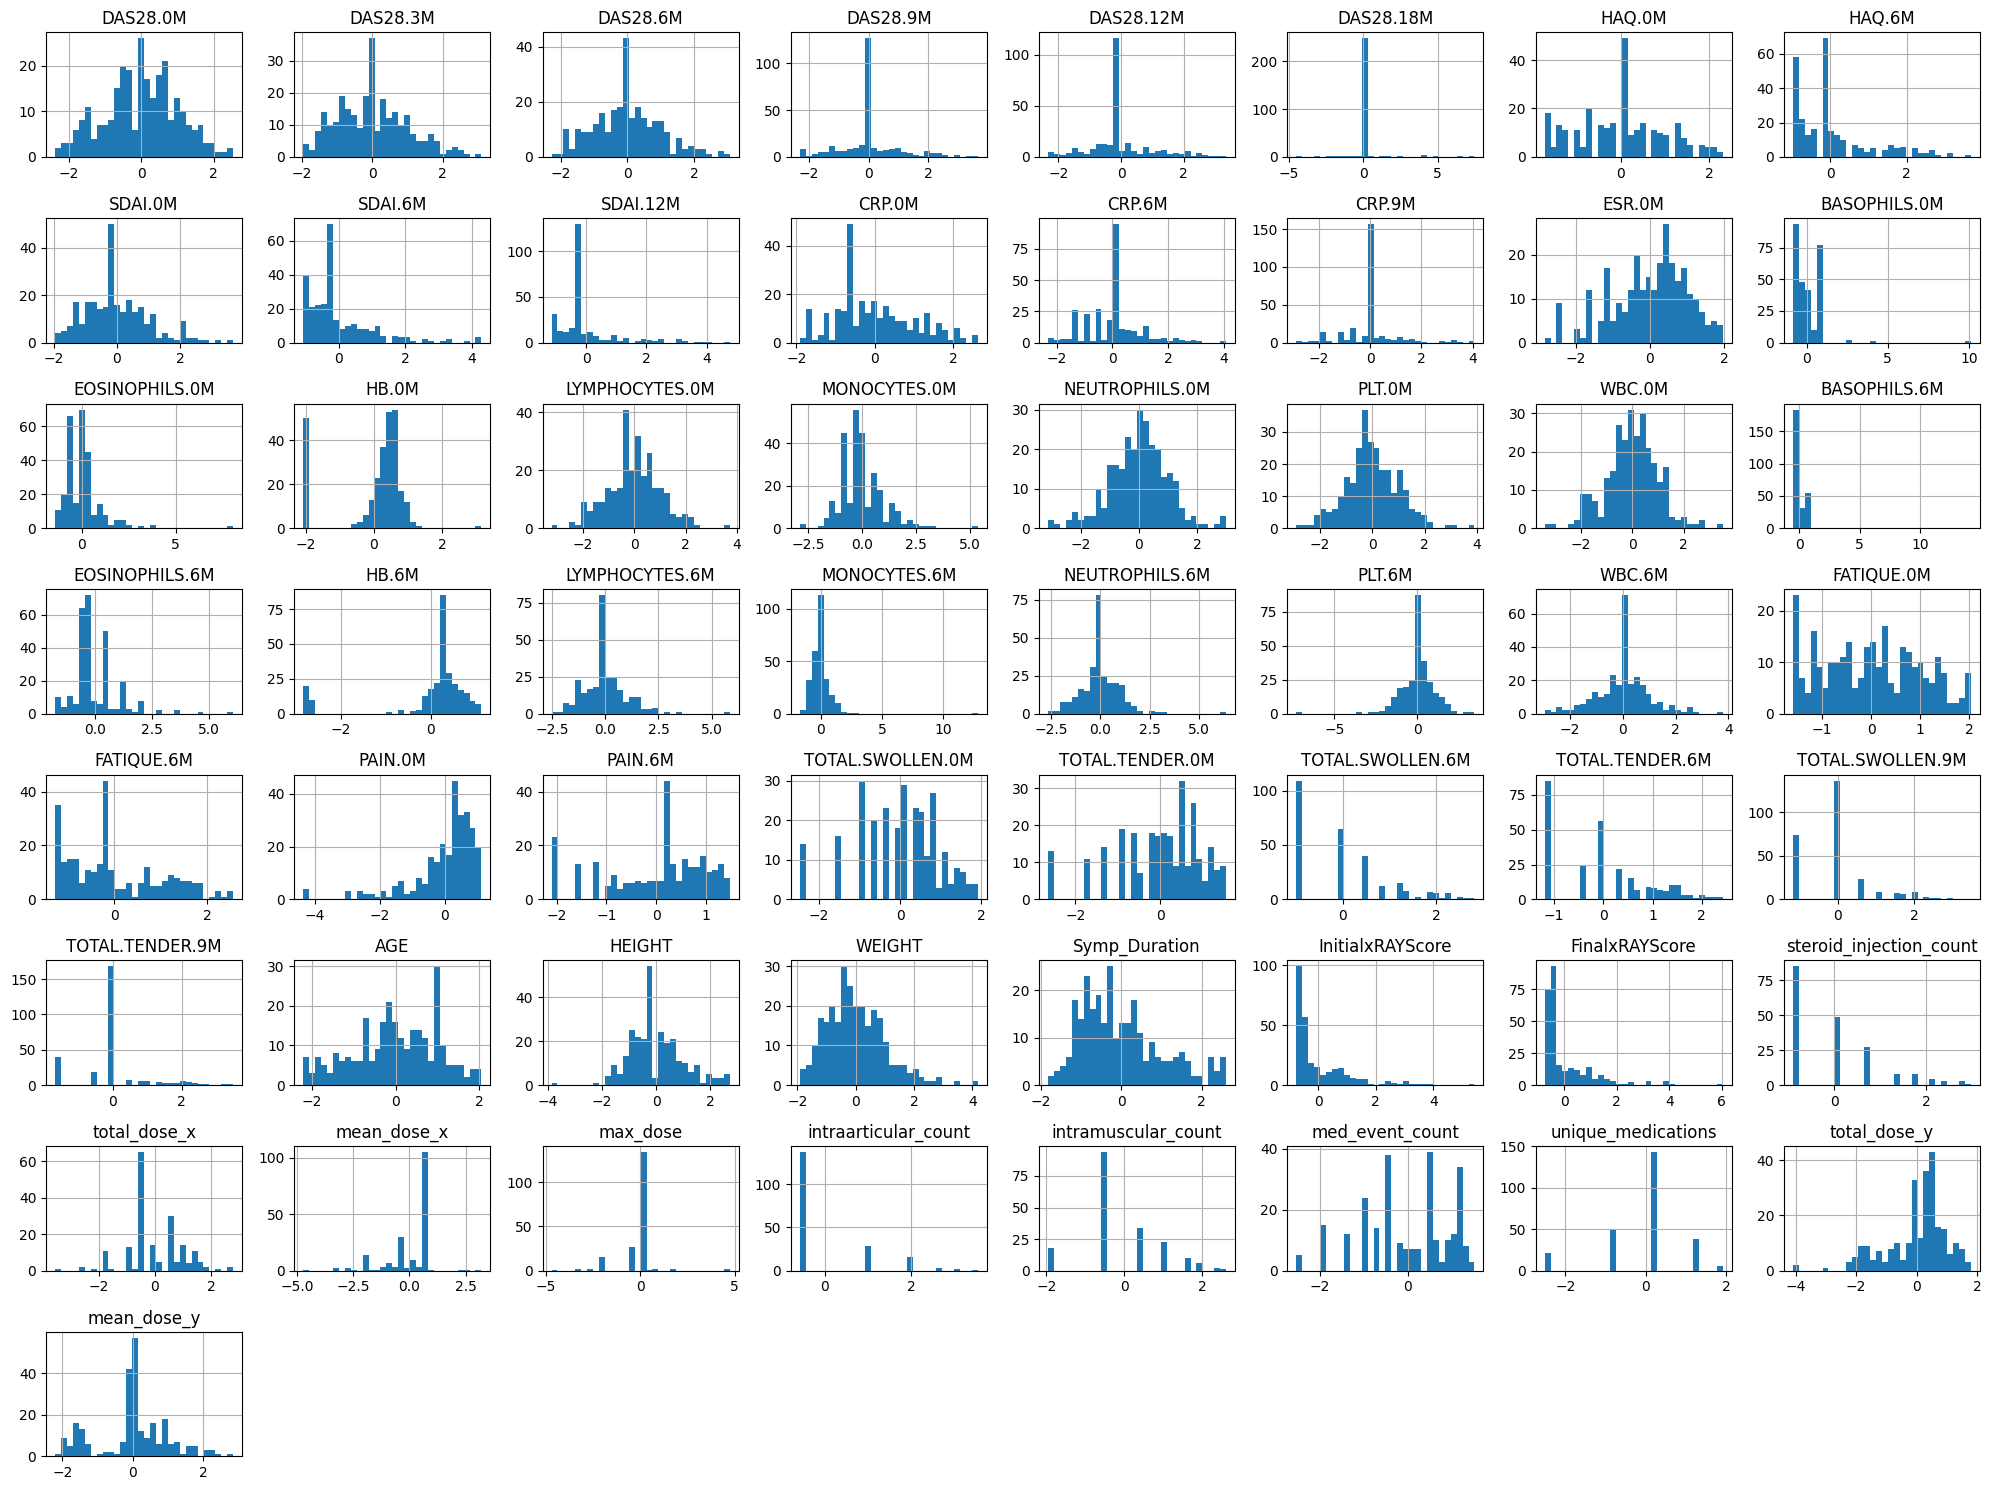

BASOPHILS.6M               10.566927
MONOCYTES.6M                7.890557
BASOPHILS.0M                4.189844
EOSINOPHILS.0M              2.773351
DAS28.18M                   2.688738
FinalxRAYScore              2.410901
SDAI.12M                    2.106667
InitialxRAYScore            2.078999
SDAI.6M                     1.869417
EOSINOPHILS.6M              1.867914
intraarticular_count        1.510609
HAQ.6M                      1.346972
LYMPHOCYTES.6M              1.010608
MONOCYTES.0M                0.981897
steroid_injection_count     0.955292
NEUTROPHILS.6M              0.937241
TOTAL.SWOLLEN.9M            0.902948
WEIGHT                      0.787990
Symp_Duration               0.750048
TOTAL.SWOLLEN.6M            0.711671
dtype: float64

In [31]:
numeric_cols = (
    CLINICAL_CONTRACT_POST["longitudinal_numeric"] +
    CLINICAL_CONTRACT_POST["static_numeric"] +
    STEROID_FEATURES_CONTRACT_POST["numeric_columns"] +
    MEDS_FEATURES_CONTRACT_POST["numeric_columns"]
)

numeric_cols = [c for c in numeric_cols if c in df_processed.columns]

import matplotlib.pyplot as plt

df_processed[numeric_cols].hist(bins=30, figsize=(20, 15))
plt.tight_layout()
plt.show()


df_processed[numeric_cols].skew().sort_values(ascending=False).head(20)

## Export to .csv

In [29]:
df_processed.to_csv('../../datasets/Clinical_Merged_Normalised.csv')